# Predicción del consumo de Combustible (MPG)
En esta sección se analizará el problema de predicción del rendimeinto de combustible utilizando modelos lineales y técnicas de regularización.

El conjunto de datos utilizado corresponde al dataset procesado previamente en la sección de EDA.

Los modelos implementados son:
- Regresión Lineal (OLS)
- Ridge Regression
- LASSO
- Elastic Net

El análisis exploratorio mostró una alta correlación entre las variables weight, displacement, horsepower y cylinders. Debido a esta posible multicolinealidad, se evaluaron técnicas de regularización como Ridge, LASSO y Elastic Net para analizar si la contracción de coeficientes mejoraba la capacidad predictiva respecto al modelo OLS.

La comparación se realiza utilizando las métricas:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coeficiente de determinación)

In [44]:
# 1. Carga del dataset procesado y separación de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/proyecto-auto-mpg'

train = pd.read_csv(f'{PROJECT}/data/train_scaled.csv')
test  = pd.read_csv(f'{PROJECT}/data/test_scaled.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# 2. Separación de variables explicativas y variable objetivo

x_entreno = train.drop(columns=["mpg"])
y_entreno = train["mpg"]

x_prueba = test.drop(columns=["mpg"])
y_prueba = test["mpg"]

print("Entrenamiento:", x_entreno.shape)
print("Prueba:", x_prueba.shape)

Entrenamiento: (318, 8)
Prueba: (80, 8)


In [46]:
# 3. Revisión rápida de los datos de entrenamiento

print("\nPromedio de mpg en entrenamiento:", y_entreno.mean().round(3))
print("Promedio de mpg en prueba:", y_prueba.mean().round(3))

print("\nPrimeras filas de entrenamiento:")
print(x_entreno.head())


Promedio de mpg en entrenamiento: 23.608
Promedio de mpg en prueba: 23.143

Primeras filas de entrenamiento:
   displacement  cylinders  horsepower    weight  acceleration  model_year  \
0      1.090196   1.527188    1.265821  0.552826     -1.319334   -1.696667   
1     -0.922996  -0.850515   -0.408635 -0.999667     -0.413182   -1.696667   
2     -0.981350  -0.850515   -0.948782 -1.124772      0.927922    1.638975   
3     -0.981350  -0.850515   -1.164840 -1.392854      0.275493    0.527094   
4     -0.747936  -0.850515   -0.219583 -0.327675     -0.231952   -0.306816   

   origin_2  origin_3  
0         0         0  
1         0         1  
2         0         1  
3         0         1  
4         1         0  


#  Regresión Lineal Base

La regresión lineal se utiliza como modelo de referencia (baseline).

El objetivo es establecer un punto de comparación antes de aplicar técnicas de regularización.

Posteriormente se comparará este modelo con Ridge, LASSO y Elastic Net para evaluar si la regularización mejora la capacidad predictiva o la interpretabilidad del modelo.

In [47]:
# 4. Modelo lineal base

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
modelo_base = LinearRegression()
modelo_base.fit(x_entreno, y_entreno)

y_pred_base = modelo_base.predict(x_prueba)

mae_base = mean_absolute_error(y_prueba, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_prueba, y_pred_base))
r2_base = r2_score(y_prueba, y_pred_base)

print("Modelo base: regresión lineal")
print("MAE: ", round(mae_base, 4))
print("RMSE:", round(rmse_base, 4))
print("R2:  ", round(r2_base, 4))

Modelo base: regresión lineal
MAE:  2.2882
RMSE: 2.8877
R2:   0.8449


In [48]:
# 5. Coeficientes del modelo base

coef_base = pd.DataFrame({
    "variable": x_entreno.columns,
    "coeficiente": modelo_base.coef_})

coef_base

,variable,coeficiente
0,displacement,2.033373
1,cylinders,-0.278695
2,horsepower,-0.539182
3,weight,-5.914735
4,acceleration,0.187514
5,model_year,2.971431
6,origin_2,2.946907
7,origin_3,2.671126


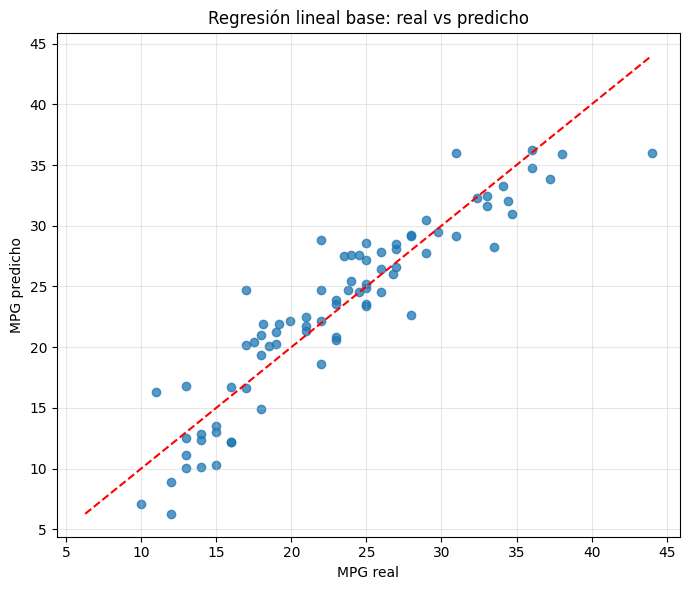

In [19]:
# 6. Gráfica simple de predicción vs valor real

plt.figure(figsize=(7, 6))
plt.scatter(y_prueba, y_pred_base, alpha=0.75)

minimo = min(y_prueba.min(), y_pred_base.min())
maximo = max(y_prueba.max(), y_pred_base.max())

plt.plot([minimo, maximo], [minimo, maximo], color="red", linestyle="--")
plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.title("Regresión lineal base: real vs predicho")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ridge Regression

Ridge añade una penalización a la función de pérdida.

Su objetivo es reducir la magnitud de los coeficientes y disminuir la sensibilidad del modelo ante posibles problemas de multicolinealidad.

El parámetro de regularización se selecciona mediante validación cruzada.

In [49]:
# 7. Ridge con validación cruzada

from sklearn.linear_model import RidgeCV

alfas = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alfas, cv=5)
ridge_cv.fit(x_entreno, y_entreno)

y_pred_ridge = ridge_cv.predict(x_prueba)

mae_ridge = mean_absolute_error(y_prueba, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_prueba, y_pred_ridge))
r2_ridge = r2_score(y_prueba, y_pred_ridge)

print("Modelo Ridge")
print("Mejor alpha:", ridge_cv.alpha_)
print("MAE: ", round(mae_ridge, 4))
print("RMSE:", round(rmse_ridge, 4))
print("R2:  ", round(r2_ridge, 4))

Modelo Ridge
Mejor alpha: 1.873817422860385
MAE:  2.2895
RMSE: 2.8914
R2:   0.8445


In [50]:
# 8. Coeficientes de Ridge

coef_ridge = pd.DataFrame({
    "variable": x_entreno.columns,
    "coeficiente": ridge_cv.coef_})

coef_ridge["magnitud"] = coef_ridge["coeficiente"].abs()
coef_ridge = coef_ridge.sort_values(by="magnitud", ascending=False).drop(columns="magnitud")

coef_ridge

,variable,coeficiente
3,weight,-5.522669
5,model_year,2.914158
6,origin_2,2.601241
7,origin_3,2.406500
0,displacement,1.437759
2,horsepower,-0.569399
1,cylinders,-0.182313
4,acceleration,0.111520


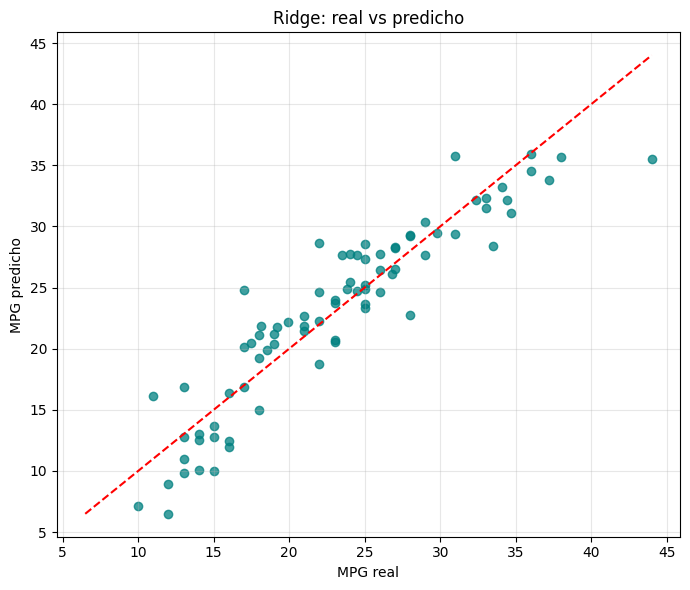

In [51]:
# 9. Gráfica real vs predicho para Ridge

plt.figure(figsize=(7, 6))
plt.scatter(y_prueba, y_pred_ridge, alpha=0.75, color="teal")

minimo = min(y_prueba.min(), y_pred_ridge.min())
maximo = max(y_prueba.max(), y_pred_ridge.max())

plt.plot([minimo, maximo], [minimo, maximo], color="red", linestyle="--")
plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.title("Ridge: real vs predicho")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# LASSO

LASSO también incorpora una penalización.

A diferencia de Ridge, puede llevar algunos coeficientes exactamente a cero, realizando selección automática de variables.

Esto permite identificar cuáles variables aportan información relevante para la predicción del MPG.

In [52]:
# 10. LASSO con validación cruzada

from sklearn.linear_model import LassoCV

modelo_lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=100000)

modelo_lasso.fit(x_entreno, y_entreno)

y_pred_lasso = modelo_lasso.predict(x_prueba)

mae_lasso = mean_absolute_error(y_prueba, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_prueba, y_pred_lasso))
r2_lasso = r2_score(y_prueba, y_pred_lasso)

print("Modelo LASSO")
print("Mejor alpha:", modelo_lasso.alpha_)
print("MAE: ", round(mae_lasso, 4))
print("RMSE:", round(rmse_lasso, 4))
print("R2:  ", round(r2_lasso, 4))

Modelo LASSO
Mejor alpha: 0.013162285657977687
MAE:  2.2935
RMSE: 2.9085
R2:   0.8427


In [53]:
# 11. Coeficientes de LASSO

coef_lasso = pd.DataFrame({
    "variable": x_entreno.columns,
    "coeficiente": modelo_lasso.coef_})

coef_lasso["magnitud"] = coef_lasso["coeficiente"].abs()

coef_lasso = coef_lasso.sort_values(
    by="magnitud",
    ascending=False)

coef_lasso.drop(columns="magnitud")

,variable,coeficiente
3,weight,-5.725234
5,model_year,2.941356
6,origin_2,2.600798
7,origin_3,2.346472
0,displacement,1.324264
2,horsepower,-0.404670
4,acceleration,0.156287
1,cylinders,-0.000000


LASSO eliminó completamente la variable cylinders, asignándole un coeficiente igual a cero. Esto indica que la información aportada por el número de cilindros ya está representada por otras variables altamente correlacionadas, como weight, horsepower y displacement. Este comportamiento constituye un ejemplo práctico de selección automática de variables mediante regularización.

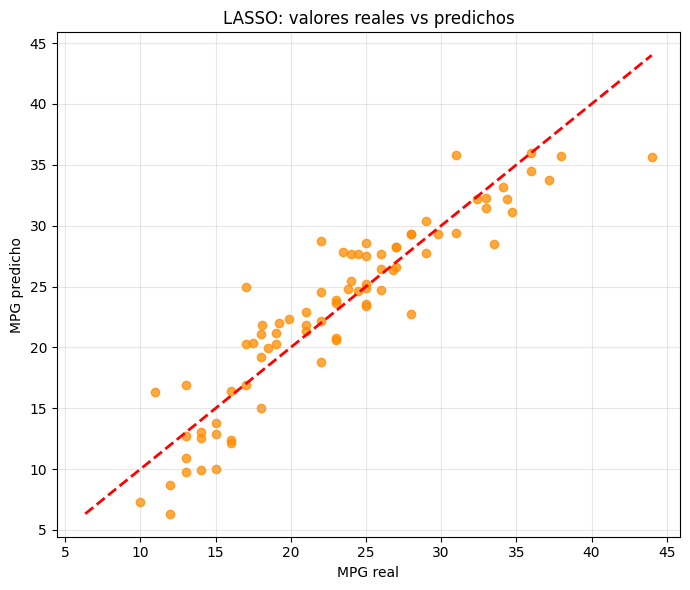

In [54]:
# 12. Gráfica real vs predicho para LASSO

plt.figure(figsize=(7,6))

plt.scatter(
    y_prueba,
    y_pred_lasso,
    alpha=0.75,
    color="darkorange")

valor_min = min(y_prueba.min(), y_pred_lasso.min())
valor_max = max(y_prueba.max(), y_pred_lasso.max())

plt.plot(
    [valor_min, valor_max],
    [valor_min, valor_max],
    color="red",
    linestyle="--",
    linewidth=2)

plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.title("LASSO: valores reales vs predichos")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Elastic Net

Elastic Net combina las penalizaciones de Ridge y LASSO.

Este modelo busca aprovechar simultáneamente la capacidad de selección de variables de LASSO y la estabilidad de Ridge.

In [55]:
# 13. Elastic Net con validación cruzada

from sklearn.linear_model import ElasticNetCV

modelo_elastic = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    cv=5,
    random_state=42,
    max_iter=100000)

modelo_elastic.fit(x_entreno, y_entreno)

y_pred_elastic = modelo_elastic.predict(x_prueba)

mae_elastic = mean_absolute_error(y_prueba, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_prueba, y_pred_elastic))
r2_elastic = r2_score(y_prueba, y_pred_elastic)

print("Elastic Net")
print("Mejor alpha:", modelo_elastic.alpha_)
print("Mejor l1_ratio:", modelo_elastic.l1_ratio_)
print("MAE:", round(mae_elastic, 4))
print("RMSE:", round(rmse_elastic, 4))
print("R2:", round(r2_elastic, 4))

Elastic Net
Mejor alpha: 0.013101801176045114
Mejor l1_ratio: 0.5
MAE: 2.2961
RMSE: 2.9037
R2: 0.8432


In [56]:
# 14. Coeficientes de Elastic Net

coef_elastic = pd.DataFrame({
    "variable": x_entreno.columns,
    "coeficiente": modelo_elastic.coef_})

coef_elastic["magnitud"] = coef_elastic["coeficiente"].abs()

coef_elastic = coef_elastic.sort_values(
    by="magnitud",
    ascending=False)

coef_elastic.drop(columns="magnitud")

,variable,coeficiente
3,weight,-5.406403
5,model_year,2.895157
6,origin_2,2.423383
7,origin_3,2.245139
0,displacement,1.083092
2,horsepower,-0.517845
4,acceleration,0.090304
1,cylinders,-0.052939


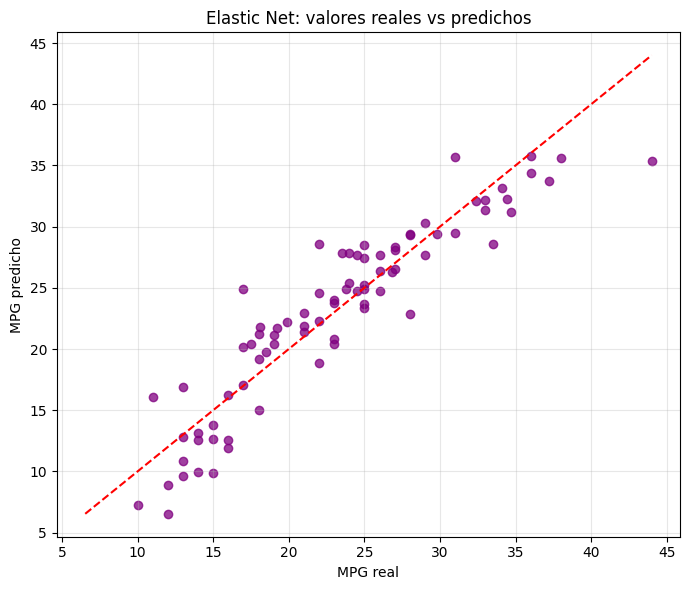

In [57]:
# 15. Real vs predicho - Elastic Net

plt.figure(figsize=(7,6))

plt.scatter(
    y_prueba,
    y_pred_elastic,
    alpha=0.75,
    color="purple")

valor_min = min(y_prueba.min(), y_pred_elastic.min())
valor_max = max(y_prueba.max(), y_pred_elastic.max())

plt.plot(
    [valor_min, valor_max],
    [valor_min, valor_max],
    color="red",
    linestyle="--")

plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.title("Elastic Net: valores reales vs predichos")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# 16. Comparación de modelos

resumen_modelos = pd.DataFrame({
    "Modelo": ["OLS", "Ridge", "LASSO", "Elastic Net"],
    "MAE": [mae_base, mae_ridge, mae_lasso, mae_elastic],
    "RMSE": [rmse_base, rmse_ridge, rmse_lasso, rmse_elastic],
    "R2": [r2_base, r2_ridge, r2_lasso, r2_elastic]})

resumen_modelos = resumen_modelos.round(4)

resumen_modelos.sort_values(
    by="R2",
    ascending=False)

,Modelo,MAE,RMSE,R2
0,OLS,2.2882,2.8877,0.8449
1,Ridge,2.2895,2.8914,0.8445
3,Elastic Net,2.2961,2.9037,0.8432
2,LASSO,2.2935,2.9085,0.8427


En este conjunto de datos, OLS obtuvo el mejor desempeño global al presentar el menor RMSE, el menor MAE y el mayor $R^2$. Esto sugiere que, para estos datos, la relación lineal describe razonablemente bien el comportamiento del MPG y que la regularización no aportó una mejora predictiva sustancial.

A continuación se analizan los residuos del modelo OLS. Los residuos corresponden a la diferencia entre el valor observado y el valor predicho. Su análisis permite detectar sesgos sistemáticos, evaluar la dispersión del error y verificar si el modelo presenta patrones no explicados.

In [59]:
# 17. Residuos de OLS

residuos = y_prueba - y_pred_base

print("Promedio del error:", residuos.mean())
print("Desviación estándar:", residuos.std())

Promedio del error: 0.07175153597839182
Desviación estándar: 2.90499512114562


Esta gráfica muestra la distribución de los residuos del modelo base. Un buen ajuste suele reflejarse en una distribución centrada alrededor de cero y sin sesgos marcados. Si la mayoría de los errores se concentran cerca de cero, significa que el modelo predice razonablemente bien. Además, la presencia de colas largas o valores extremos puede indicar observaciones difíciles de explicar con una relación lineal simple.

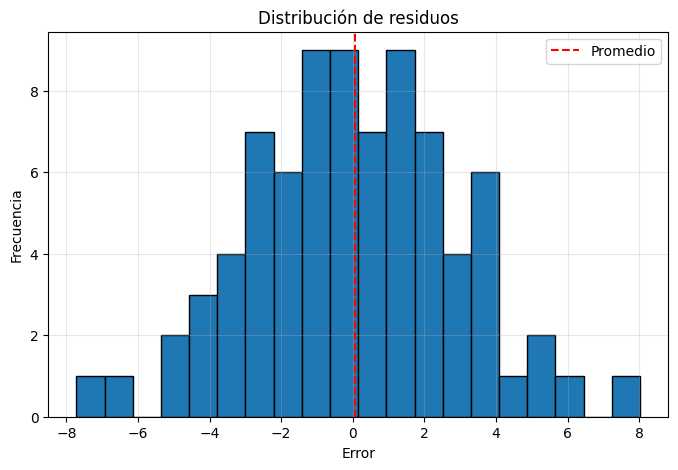

In [60]:
# 18. Distribución de errores

plt.figure(figsize=(8,5))

plt.hist(
    residuos,
    bins=20,
    edgecolor="black")

plt.axvline(
    residuos.mean(),
    color="red",
    linestyle="--",
    label="Promedio")

plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Aquí se analiza la relación entre el valor real de MPG y el error cometido por el modelo. La línea horizontal en cero representa predicción perfecta. Si los errores se dispersan de manera aleatoria alrededor de esa línea, el modelo no presenta un patrón sistemático grave. En cambio, si se observa alguna tendencia, podría indicar que el modelo tiene dificultades en ciertos rangos de consumo.

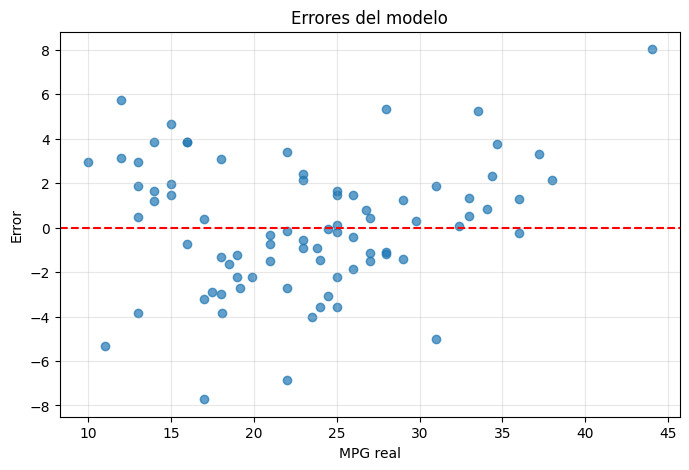

In [33]:
# 19. Valor real vs error

plt.figure(figsize=(8,5))

plt.scatter(
    y_prueba,
    residuos,
    alpha=0.7)

plt.axhline(
    0,
    color="red",
    linestyle="--")

plt.xlabel("MPG real")
plt.ylabel("Error")

plt.title("Errores del modelo")

plt.grid(alpha=0.3)

plt.show()

En esta tabla se comparan los coeficientes estimados por los cuatro modelos lineales: OLS, Ridge, LASSO y Elastic Net. Esta comparación permite observar cómo cada técnica modifica la magnitud de los parámetros según su esquema de regularización. Mientras OLS no penaliza los coeficientes, Ridge tiende a reducirlos, LASSO puede llevar algunos a cero y Elastic Net combina ambos efectos.

In [35]:
# 20. Comparación de coeficientes

tabla_coeficientes = pd.DataFrame({
    "Variable": x_entreno.columns,
    "OLS": modelo_base.coef_,
    "Ridge": ridge_cv.coef_,
    "LASSO": modelo_lasso.coef_,
    "ElasticNet": modelo_elastic.coef_})

tabla_coeficientes = tabla_coeficientes.round(4)

tabla_coeficientes

,Variable,OLS,Ridge,LASSO,ElasticNet
0,displacement,2.0334,1.4378,1.3243,1.0831
1,cylinders,-0.2787,-0.1823,-0.0000,-0.0529
2,horsepower,-0.5392,-0.5694,-0.4047,-0.5178
3,weight,-5.9147,-5.5227,-5.7252,-5.4064
4,acceleration,0.1875,0.1115,0.1563,0.0903
5,model_year,2.9714,2.9142,2.9414,2.8952
6,origin_2,2.9469,2.6012,2.6008,2.4234
7,origin_3,2.6711,2.4065,2.3465,2.2451


Los coeficientes muestran que el peso (weight) es la variable con mayor influencia negativa sobre el MPG, mientras que el año del modelo (model_year) presenta una influencia positiva importante. Asimismo, las variables origin_2 y origin_3 sugieren que los vehículos europeos y japoneses presentan una eficiencia de combustible superior a los vehículos estadounidenses de referencia.

A partir de los coeficientes del modelo OLS, se obtiene una medida aproximada de la importancia relativa de las variables usando el valor absoluto de cada coeficiente.

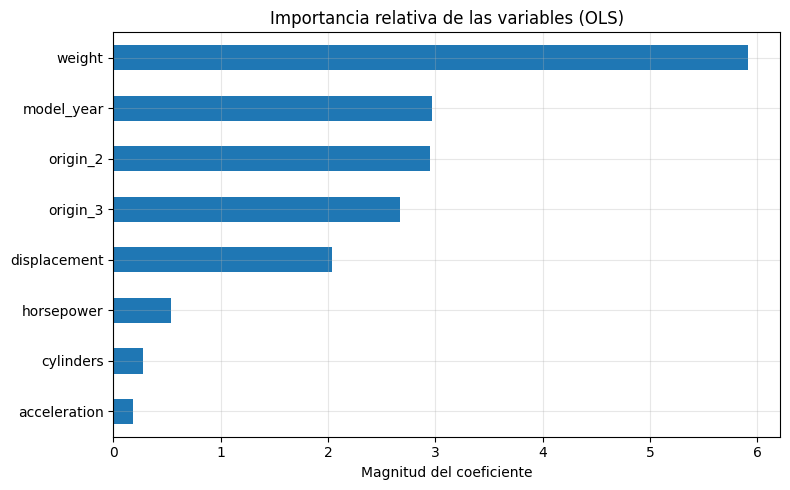

In [38]:
# 21. Magnitud de los coeficientes OLS

coef_ordenados = (
    pd.Series(
        modelo_base.coef_,
        index=x_entreno.columns)
    .abs()
    .sort_values())

plt.figure(figsize=(8,5))

coef_ordenados.plot(kind="barh")

plt.xlabel("Magnitud del coeficiente")
plt.title("Importancia relativa de las variables (OLS)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

En esta gráfica se comparan los coeficientes de cada variable a través de los distintos modelos lineales. Esto permite observar cómo cambia la estimación de los parámetros al aplicar regularización.

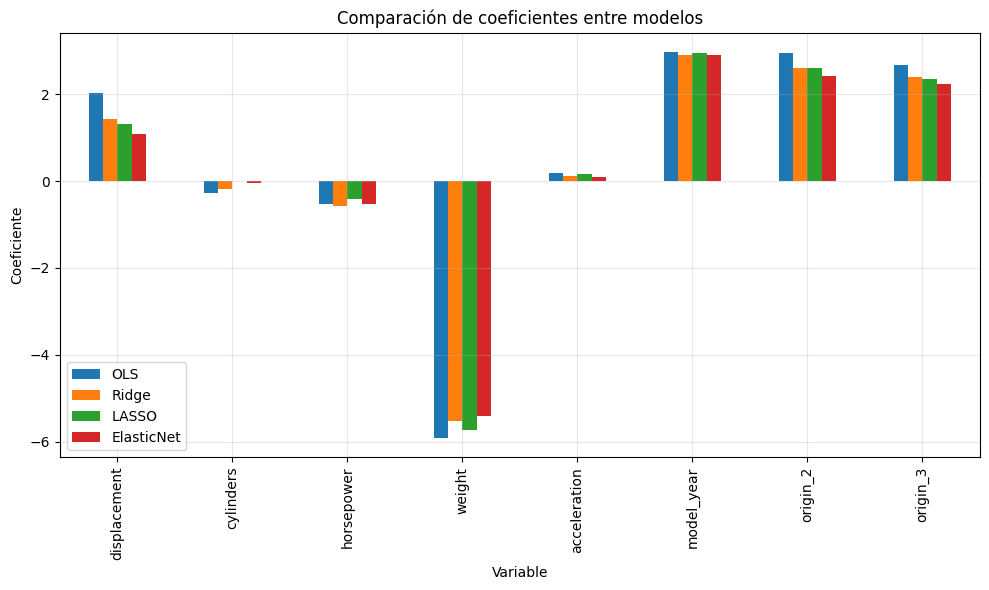

In [39]:
# 22. Comparación entre modelos

tabla_grafica = tabla_coeficientes.set_index("Variable")

tabla_grafica.plot(
    kind="bar",
    figsize=(10,6))

plt.ylabel("Coeficiente")

plt.title(
    "Comparación de coeficientes entre modelos")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# 23. Tabla final de resultados

resumen_final = pd.DataFrame({
    "Modelo": ["OLS", "Ridge", "LASSO", "Elastic Net"],
    "MAE": [mae_base, mae_ridge, mae_lasso, mae_elastic],
    "RMSE": [rmse_base, rmse_ridge, rmse_lasso, rmse_elastic],
    "R2": [r2_base, r2_ridge, r2_lasso, r2_elastic]})

resumen_final = resumen_final.round(4)

resumen_final

,Modelo,MAE,RMSE,R2
0,OLS,2.2882,2.8877,0.8449
1,Ridge,2.2895,2.8914,0.8445
2,LASSO,2.2935,2.9085,0.8427
3,Elastic Net,2.2961,2.9037,0.8432


Finalmente, se selecciona el mejor modelo con base en tres criterios distintos: RMSE, MAE y R².

In [43]:
# 24. Elegir el mejor modelo según RMSE, MAE o R2

mejor_rmse = resumen_final.sort_values("RMSE").iloc[0]
mejor_mae = resumen_final.sort_values("MAE").iloc[0]
mejor_r2 = resumen_final.sort_values("R2", ascending=False).iloc[0]

print("Mejor modelo por RMSE:", mejor_rmse["Modelo"])
print("Mejor modelo por MAE:", mejor_mae["Modelo"])
print("Mejor modelo por R²:", mejor_r2["Modelo"])

Mejor modelo por RMSE: OLS
Mejor modelo por MAE: OLS
Mejor modelo por R²: OLS


# Conclusiones
En este conjunto de datos, el modelo OLS presentó el mejor desempeño global al obtener simultáneamente el menor MAE, el menor RMSE y el mayor R². Esto indica que la relación lineal entre las características técnicas de los automóviles y su consumo de combustible explica de manera razonable la variación del MPG.

Los métodos de regularización, aunque útiles para controlar la magnitud de los coeficientes y reducir la complejidad del modelo, no mejoraron de forma significativa el rendimiento predictivo en este caso. Ridge quedó muy cerca de OLS, mientras que LASSO y Elastic Net presentaron una ligera disminución en el ajuste.

Desde el punto de vista interpretativo, el peso del vehículo fue la variable con mayor influencia negativa sobre el MPG, mientras que el año del modelo mostró un efecto positivo importante. Además, LASSO anuló el coeficiente de cylinders, lo que sugiere redundancia con otras variables correlacionadas como weight, displacement y horsepower.

En conjunto, los resultados muestran que el consumo de combustible puede explicarse razonablemente bien con modelos lineales, y que para este problema la regularización aporta más estabilidad e interpretabilidad que una mejora clara en precisión.